In [ ]:
import kagglehub
path = kagglehub.dataset_download("rohitdurbha/alibaba-cluster-data")

100%|██████████| 1.22G/1.22G [00:14<00:00, 92.0MB/s]

Extracting files...


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import glob
import os

In [ ]:
# Find all CSV files
found_csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)

# Filter specifically for batch_instance.csv
target_file = [f for f in found_csv_files if 'batch_instance.csv' in f][0]
data = pd.read_csv(target_file)

# Re-apply median imputation
for col in ['cpu_avg', 'cpu_max', 'mem_avg', 'mem_max']:
    if data[col].isnull().any():
        median_val = data[col].median()
        data[col] = data[col].fillna(median_val)

print(f"Successfully loaded and preprocessed: {os.path.basename(target_file)}")

Successfully loaded and preprocessed: batch_instance.csv


In [ ]:
print(f"Numbers of Rows: {data.shape[0]}")
print(f"Numbers of Columns: {data.shape[1]}")

Numbers of Rows: 15000000
Numbers of Columns: 14


In [ ]:
data.head()

,instance_name,task_name,job_name,task_type,status,start_time,end_time,machine_id,seq_no,total_seq_no,cpu_avg,cpu_max,mem_avg,mem_max
0,ins_74901673,task_LTg0MTUwNTA5Mjg4MDkwNjIzMA==,j_217,10,Terminated,673795,673797,m_2637,1,1,13.0,16.0,0.02,0.02
1,ins_815802872,M1,j_1527,1,Terminated,158478,158520,m_3430,1,1,3.0,19.0,0.13,0.18
2,ins_564677701,M1,j_2014,1,Terminated,372602,372616,m_1910,1,1,87.0,116.0,0.04,0.05
3,ins_257566161,M1,j_2014,1,Terminated,372602,372615,m_2485,1,1,91.0,123.0,0.05,0.05
4,ins_688679908,M1,j_2014,1,Terminated,372602,372615,m_993,1,1,93.0,141.0,0.05,0.05


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000000 entries, 0 to 14999999
Data columns (total 14 columns):
 #   Column         Dtype  
---  ------         -----  
 0   instance_name  object 
 1   task_name      object 
 2   job_name       object 
 3   task_type      int64  
 4   status         object 
 5   start_time     int64  
 6   end_time       int64  
 7   machine_id     object 
 8   seq_no         int64  
 9   total_seq_no   int64  
 10  cpu_avg        float64
 11  cpu_max        float64
 12  mem_avg        float64
 13  mem_max        float64
dtypes: float64(4), int64(5), object(5)
memory usage: 1.6+ GB


In [ ]:
data.describe()

In [ ]:
print('Missing values per column:')
print(data.isnull().sum().sort_values(ascending=False))

Missing values per column:
instance_name    0
task_name        0
job_name         0
task_type        0
status           0
start_time       0
end_time         0
machine_id       0
seq_no           0
total_seq_no     0
cpu_avg          0
cpu_max          0
mem_avg          0
mem_max          0
dtype: int64


In [ ]:
# Impute missing values with the median for numerical columns
for col in ['cpu_avg', 'cpu_max', 'mem_avg', 'mem_max']:
    if data[col].isnull().any():
        median_val = data[col].median()
        # Corrected: Assign the result back to the column instead of using inplace=True
        data[col] = data[col].fillna(median_val)
        print(f"Missing values in '{col}' imputed with median: {median_val}")

# Verify that there are no more missing values
print('\nMissing values after imputation:')
print(data.isnull().sum().sort_values(ascending=False))


Missing values after imputation:
instance_name    0
task_name        0
job_name         0
task_type        0
status           0
start_time       0
end_time         0
machine_id       0
seq_no           0
total_seq_no     0
cpu_avg          0
cpu_max          0
mem_avg          0
mem_max          0
dtype: int64


In [ ]:
resource_usage_by_task_type = data.groupby('task_type')[['cpu_avg', 'cpu_max', 'mem_avg', 'mem_max']].mean()
display(resource_usage_by_task_type)

,cpu_avg,cpu_max,mem_avg,mem_max
task_type,,,,
1,61.599446,122.182454,0.102523,0.128812
3,77.301008,105.666321,0.040152,0.054229
4,11.511628,36.860465,0.037326,0.041860
5,63.000000,95.000000,0.040000,0.050000
6,15.531896,35.165846,0.020444,0.021226
7,63.000000,95.000000,0.040000,0.050000
8,48.883766,130.772220,0.135030,0.189773
9,83.730648,299.684982,0.168298,0.202371
10,72.348451,88.813193,0.052387,0.057618


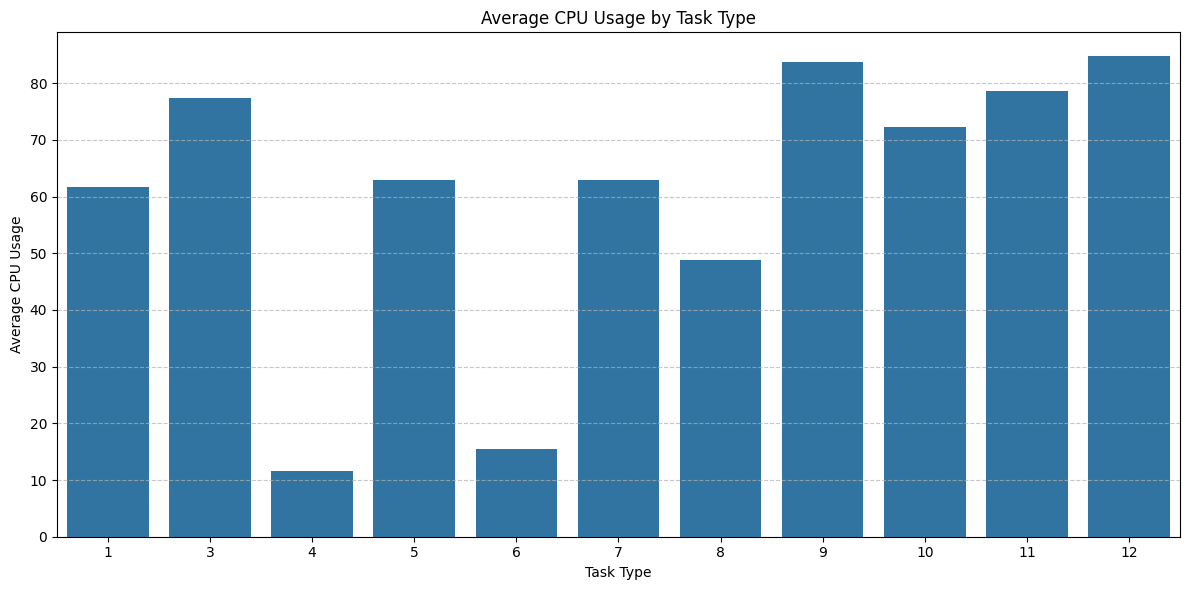

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_usage_by_task_type.index, y='cpu_avg', data=resource_usage_by_task_type)
plt.title('Average CPU Usage by Task Type')
plt.xlabel('Task Type')
plt.ylabel('Average CPU Usage')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

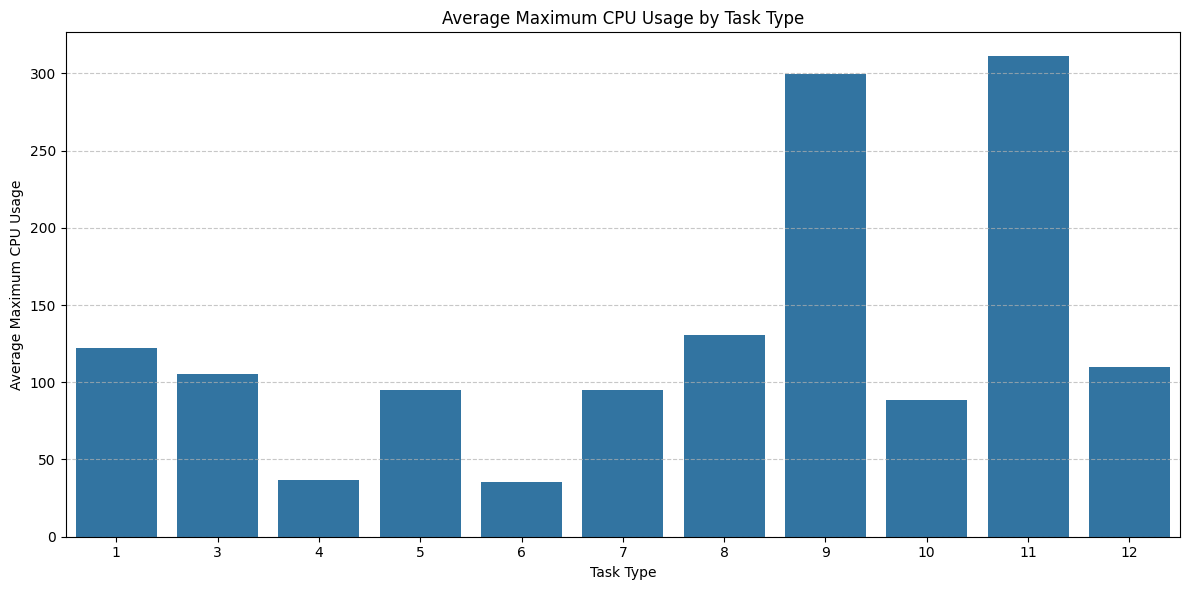

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_usage_by_task_type.index, y='cpu_max', data=resource_usage_by_task_type)
plt.title('Average Maximum CPU Usage by Task Type')
plt.xlabel('Task Type')
plt.ylabel('Average Maximum CPU Usage')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

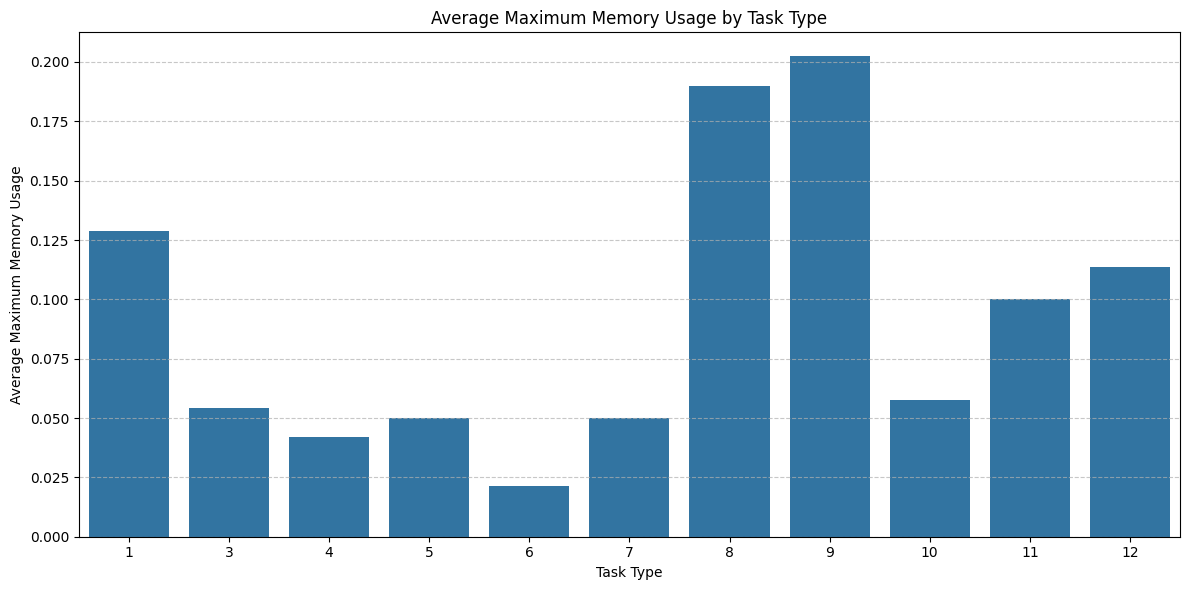

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_usage_by_task_type.index, y='mem_max', data=resource_usage_by_task_type)
plt.title('Average Maximum Memory Usage by Task Type')
plt.xlabel('Task Type')
plt.ylabel('Average Maximum Memory Usage')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

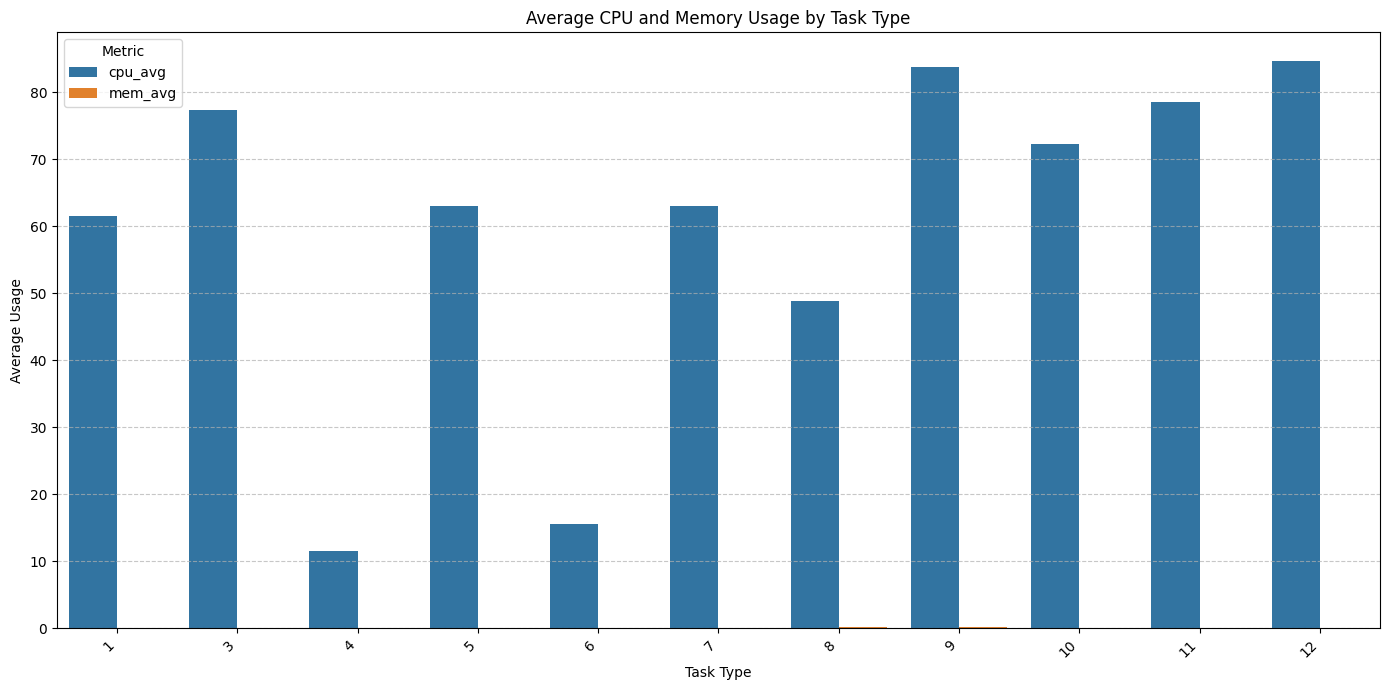

In [ ]:
resource_usage_melted = resource_usage_by_task_type[['cpu_avg', 'mem_avg']].reset_index().melt(id_vars='task_type', var_name='Metric', value_name='Average_Usage')

plt.figure(figsize=(14, 7))
sns.barplot(x='task_type', y='Average_Usage', hue='Metric', data=resource_usage_melted)
plt.title('Average CPU and Memory Usage by Task Type')
plt.xlabel('Task Type')
plt.ylabel('Average Usage')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

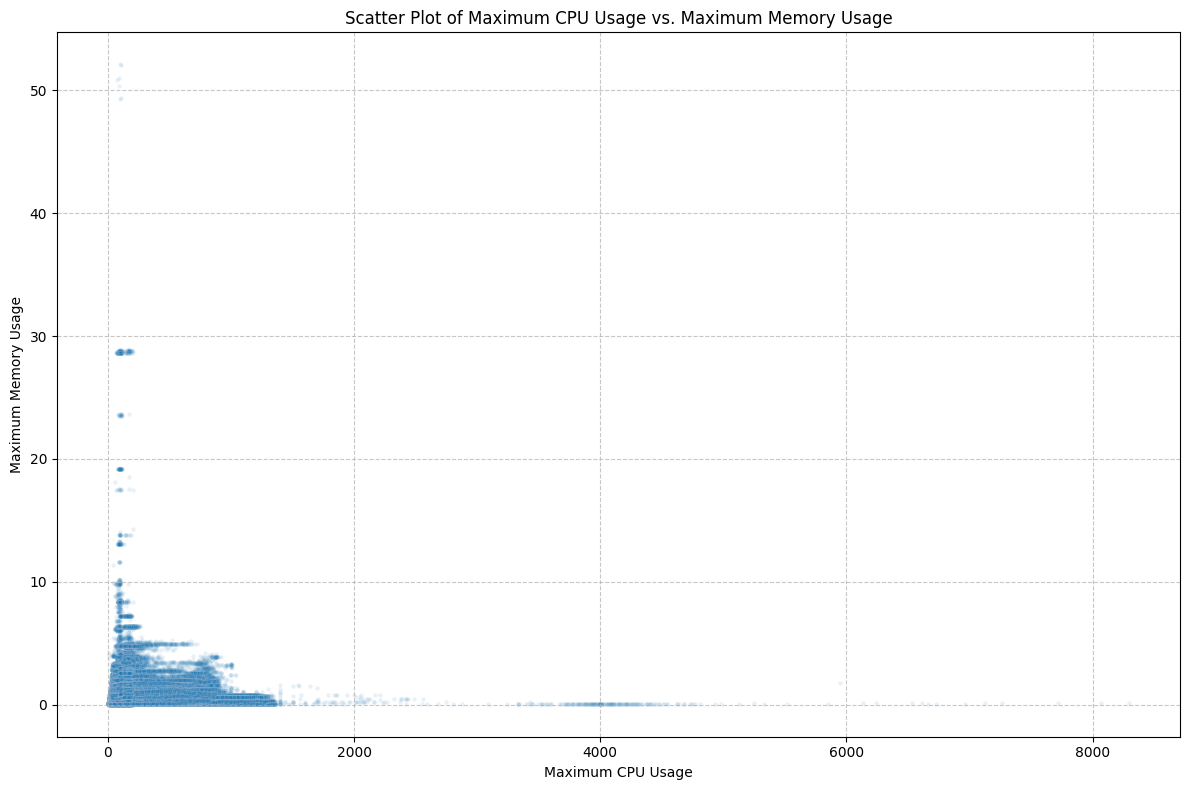

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='cpu_max', y='mem_max', data=data, alpha=0.1, s=10)
plt.title('Scatter Plot of Maximum CPU Usage vs. Maximum Memory Usage')
plt.xlabel('Maximum CPU Usage')
plt.ylabel('Maximum Memory Usage')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
numerical_cols = data.select_dtypes(include=[np.number]).columns
correlation_matrix = data[numerical_cols].corr()
display(correlation_matrix)

,task_type,start_time,end_time,seq_no,total_seq_no,cpu_avg,cpu_max,mem_avg,mem_max
task_type,1.000000,0.045617,0.042359,0.037263,0.046312,-0.078513,-0.028025,-0.016350,-0.013537
start_time,0.045617,1.000000,0.996570,-0.008523,-0.011644,0.012967,-0.012529,-0.000610,-0.002642
end_time,0.042359,0.996570,1.000000,-0.011440,-0.024600,0.012805,-0.011718,0.000202,-0.001802
seq_no,0.037263,-0.008523,-0.011440,1.000000,0.657585,0.003784,0.012916,0.003523,0.002783
total_seq_no,0.046312,-0.011644,-0.024600,0.657585,1.000000,0.003085,0.005419,-0.000684,-0.001181
cpu_avg,-0.078513,0.012967,0.012805,0.003784,0.003085,1.000000,0.570972,0.040546,0.059961
cpu_max,-0.028025,-0.012529,-0.011718,0.012916,0.005419,0.570972,1.000000,0.206488,0.250768
mem_avg,-0.016350,-0.000610,0.000202,0.003523,-0.000684,0.040546,0.206488,1.000000,0.962972
mem_max,-0.013537,-0.002642,-0.001802,0.002783,-0.001181,0.059961,0.250768,0.962972,1.000000


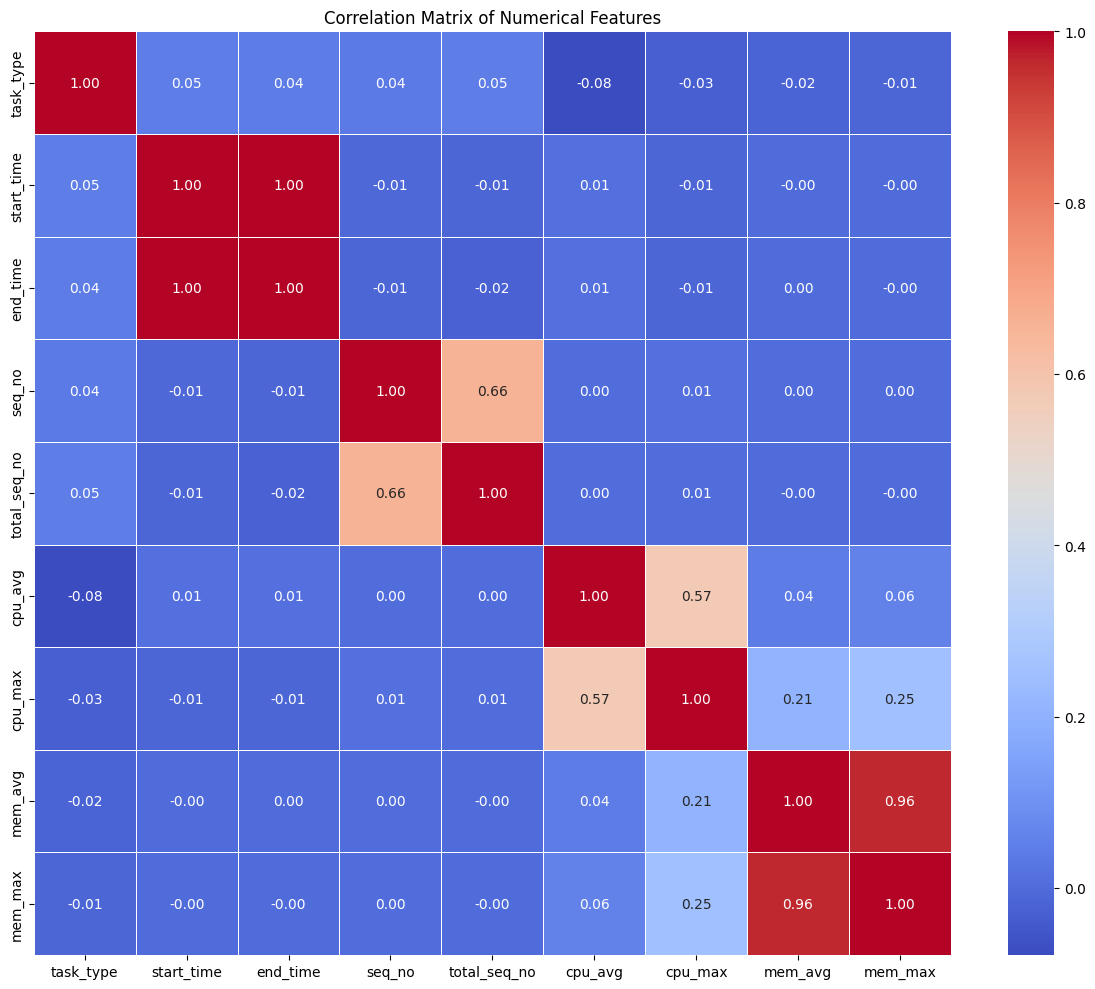

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

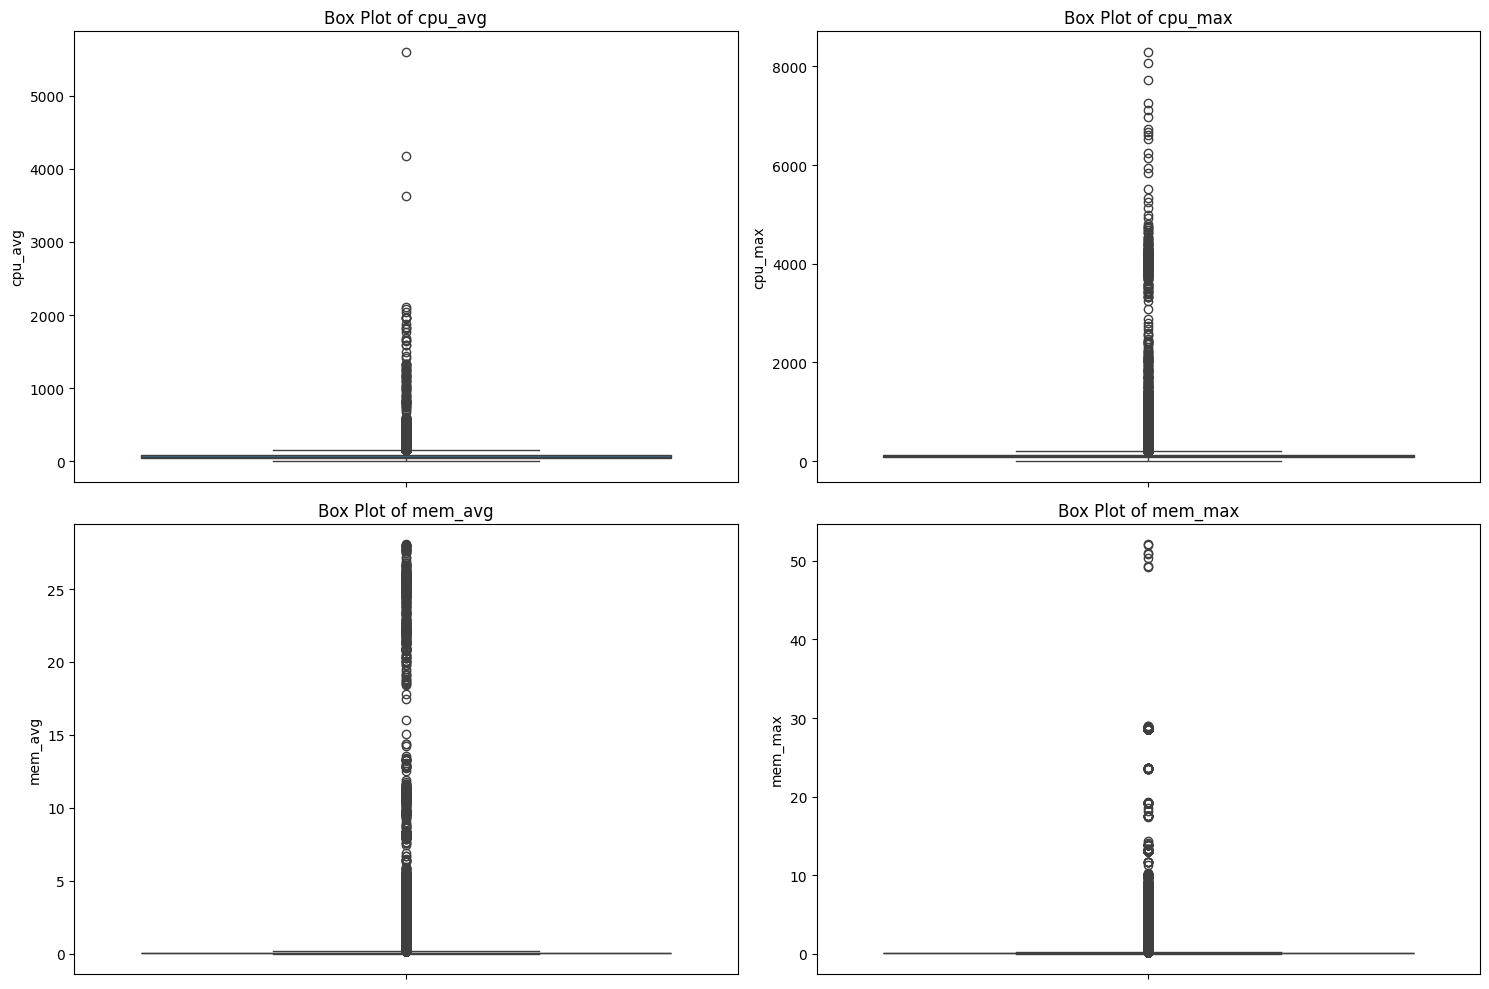

In [ ]:
resource_columns = ['cpu_avg', 'cpu_max', 'mem_avg', 'mem_max']

plt.figure(figsize=(15, 10))
for i, col in enumerate(resource_columns):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

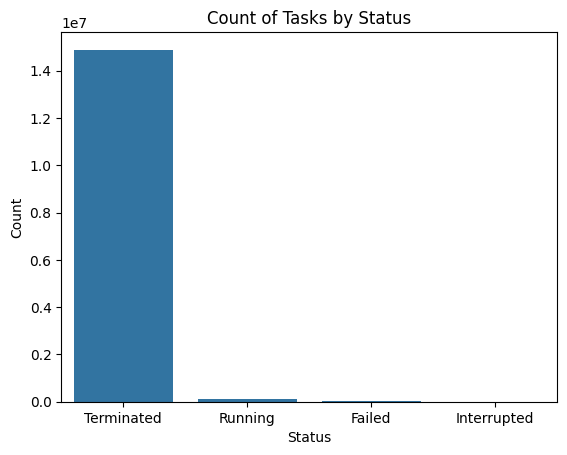

In [ ]:
sns.countplot(x='status', data=data)
plt.title('Tasks by Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode the 'status' column to numerical labels
le = LabelEncoder()
data['status_encoded'] = le.fit_transform(data['status'])

# Separate majority and minority classes based on the 'status_encoded' column
status_counts = data['status_encoded'].value_counts()

# Assuming 'Terminated' (which is likely 0 after encoding) is the majority class
# and other statuses are minority classes.
# Find the minority class (or the smallest class if there are multiple minority classes)
minority_class_label = status_counts.idxmin()
minority_class_count = status_counts.min()

# Get the DataFrame for the minority class
df_minority = data[data['status_encoded'] == minority_class_label]

# Get the DataFrame for the majority classes (all classes that are not the minority)
df_majority_all = data[data['status_encoded'] != minority_class_label]

# Randomly undersample each of the other majority classes to match the minority class count
balanced_data_frames = [df_minority]

for status_label in status_counts.index:
    if status_label != minority_class_label:
        df_current_majority = data[data['status_encoded'] == status_label]
        if len(df_current_majority) > minority_class_count:
            df_undersampled = df_current_majority.sample(n=minority_class_count, random_state=42)
            balanced_data_frames.append(df_undersampled)
        else:
            # If a 'majority' class is already smaller than or equal to minority count,
            # include it entirely
            balanced_data_frames.append(df_current_majority)

# Concatenate the balanced dataframes
data_balanced = pd.concat(balanced_data_frames, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Original dataset size: {data.shape[0]} rows")
print(f"Balanced dataset size: {data_balanced.shape[0]} rows")
print("Class distribution in balanced dataset:")
print(data_balanced['status_encoded'].value_counts())

# Optionally, you can also print the distribution of the original 'status' labels in the balanced dataset
print("\nOriginal 'status' distribution in balanced dataset:")
print(data_balanced['status'].value_counts())

# Define X and y for the balanced dataset
X_balanced = data_balanced.drop(['instance_name', 'task_name', 'job_name', 'status', 'machine_id', 'status_encoded'], axis=1)
y_balanced = data_balanced['status_encoded']

print(f"\nX_balanced shape: {X_balanced.shape}")
print(f"y_balanced shape: {y_balanced.shape}")

LSTM Model for Classification

Preprocessing data for LSTM...
X_train_lstm shape: (4662, 9, 1)
y_train_lstm shape: (4662, 4)
X_test_lstm shape: (1166, 9, 1)
y_test_lstm shape: (1166, 4)

Building LSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 9, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,804 (120.33 KB)

 Trainable params: 30,804 (120.33 KB)

 Non-trainable params: 0 (0.00 B)

LSTM model built successfully!

Training LSTM model...
Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3971 - loss: 1.2260 - val_accuracy: 0.5375 - val_loss: 1.0440
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6851 - loss: 0.8338 - val_accuracy: 0.8415 - val_loss: 0.5202
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8441 - loss: 0.4906 - val_accuracy: 0.8801 - val_loss: 0.4223
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8667 - loss: 0.4107 - val_accuracy: 0.8951 - val_loss: 0.3494
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8942 - loss: 0.3498 - val_accuracy: 0.9058 - val_loss: 0.3470
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8989 - loss: 0.3377 - val_accuracy: 0.9165 - val_loss: 0.3005
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9037 - loss: 0.3196 - val_accuracy: 0.9122 - val_loss: 0.3214
Epoch 8/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms

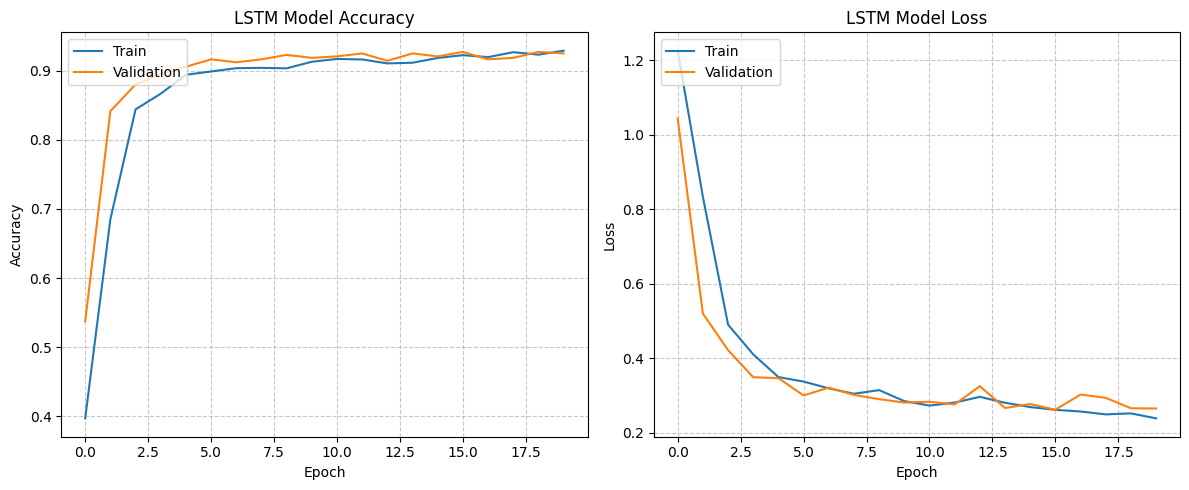


--- LSTM Model Performance ---
Test Accuracy: 0.9443
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       292
           1       0.88      1.00      0.94       291
           2       0.98      0.85      0.91       292
           3       0.99      0.96      0.97       291

    accuracy                           0.94      1166
   macro avg       0.95      0.94      0.94      1166
weighted avg       0.95      0.94      0.94      1166



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input # Import Input layer
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting
import pandas as pd # Import pandas for DataFrame if model_performance needs it

print("LSTM Model for Classification\n")

print("Preprocessing data for LSTM...")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

# Reshape data for LSTM: (samples, timesteps, features)
# For tabular data, we're treating each feature as a timestep.
# So, (n_samples, n_features, 1) where each feature is a timestep.
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# One-hot encode the target variable
y_one_hot = to_categorical(y_balanced)

# Split the data into training and testing sets
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_reshaped, y_one_hot, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

print("\nBuilding LSTM model...")

# Define the LSTM model with Input layer to avoid the UserWarning
model = Sequential([
    Input(shape=(X_train_lstm.shape[1], 1)), # Recommended way to specify input shape
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=y_train_lstm.shape[1], activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()
print("LSTM model built successfully!")

print("\nTraining LSTM model...")

history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("LSTM model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\n--- LSTM Model Performance ---")
print(f"Test Accuracy: {accuracy:.4f}")

y_pred_lstm_prob = model.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)
y_true_lstm = np.argmax(y_test_lstm, axis=1)

print("Classification Report:")
print(classification_report(y_true_lstm, y_pred_lstm))




In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

# Assuming y_true_lstm and y_pred_lstm are available from previous execution
accuracy = accuracy_score(y_true_lstm, y_pred_lstm)
print(f"LSTM Model Accuracy: {accuracy:.4f}")
# precision
precision = precision_score(y_true_lstm, y_pred_lstm, average='weighted')
print(f"LSTM Model Precision: {precision:.4f}")
#recall
recall = recall_score(y_true_lstm, y_pred_lstm, average='weighted')
print(f"LSTM Model Recall: {recall:.4f}")
#f1_score
f1 = f1_score(y_true_lstm, y_pred_lstm, average='weighted')
print(f"LSTM Model F1 Score: {f1:.4f}")

# append all in a dict
model_performance ={}
model_performance['LSTM'] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1
}


LSTM Model Accuracy: 0.9443
LSTM Model Precision: 0.9477
LSTM Model Recall: 0.9443
LSTM Model F1 Score: 0.9439


## Artificial Neural Network (ANN) Model for Classification

X_train_ann shape: (4662, 9)
y_train_ann shape: (4662, 4)
X_test_ann shape: (1166, 9)
y_test_ann shape: (1166, 4)

Building ANN model...


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,796 (38.27 KB)

 Trainable params: 9,796 (38.27 KB)

 Non-trainable params: 0 (0.00 B)

ANN model built successfully!

Training ANN model...
Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6384 - loss: 0.9437 - val_accuracy: 0.8779 - val_loss: 0.5882
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8007 - loss: 0.5765 - val_accuracy: 0.9058 - val_loss: 0.4394
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8501 - loss: 0.4795 - val_accuracy: 0.8994 - val_loss: 0.3841
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8694 - loss: 0.4084 - val_accuracy: 0.9143 - val_loss: 0.3485
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8880 - loss: 0.3761 - val_accuracy: 0.9143 - val_loss: 0.3251
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8961 - loss: 0.3520 - val_accuracy: 0.9186 - val_loss: 0.3000
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9032 - loss: 0.3209 - val_accuracy: 0.9315 - val_loss: 0.2835
Epoch 8/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

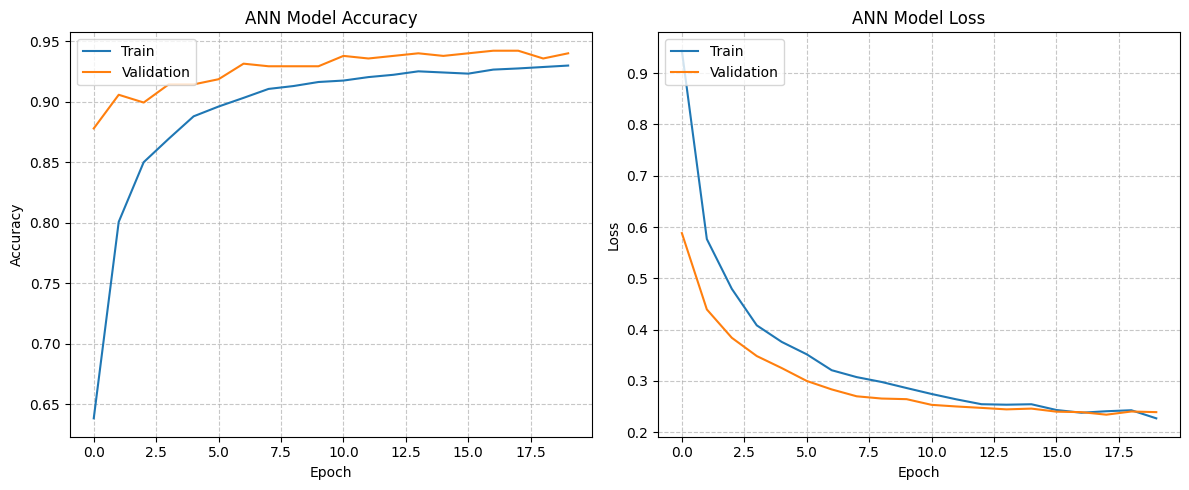


--- ANN Model Performance ---
Test Accuracy: 0.9468
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Classification Report for ANN:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       292
           1       0.89      0.98      0.93       291
           2       0.97      0.84      0.90       292
           3       1.00      0.98      0.99       291

    accuracy                           0.95      1166
   macro avg       0.95      0.95      0.95      1166
weighted avg       0.95      0.95      0.95      1166


ANN Model Precision (weighted): 0.9492
ANN Model Recall (weighted): 0.9468
ANN Model F1 Score (weighted): 0.9462

Updated model_performance dictionary with ANN results:


,accuracy,precision,recall,f1_score
LSTM,0.944254,0.947715,0.944254,0.943927
ANN,0.946827,0.949203,0.946827,0.946245


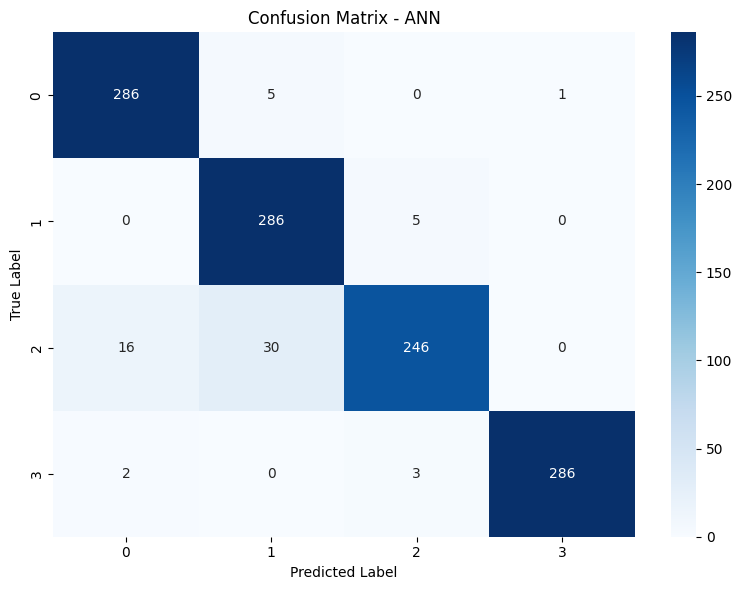

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("## Artificial Neural Network (ANN) Model for Classification\n")

# Reuse preprocessed and scaled data (X_scaled) and one-hot encoded labels (y_one_hot)
# For ANN, the input shape should be 2D (samples, features)

# Split data into training and testing sets
# Using X_scaled directly as it's already 2D (samples, features)
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_scaled, y_one_hot, test_size=0.2, random_state=42, stratify=np.argmax(y_one_hot, axis=1)
)

print(f"X_train_ann shape: {X_train_ann.shape}")
print(f"y_train_ann shape: {y_train_ann.shape}")
print(f"X_test_ann shape: {X_test_ann.shape}")
print(f"y_test_ann shape: {y_test_ann.shape}")

print("\nBuilding ANN model...")

# Define the ANN model
ann_model = Sequential([
    Input(shape=(X_train_ann.shape[1],)), # Input layer for 2D data
    Dense(units=128, activation='relu'),
    Dropout(0.3),
    Dense(units=64, activation='relu'),
    Dropout(0.3),
    Dense(units=y_train_ann.shape[1], activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

ann_model.summary()
print("ANN model built successfully!")

print("\nTraining ANN model...")

history_ann = ann_model.fit(
    X_train_ann, y_train_ann,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("ANN model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_ann.history['accuracy'])
plt.plot(history_ann.history['val_accuracy'])
plt.title('ANN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_ann.history['loss'])
plt.plot(history_ann.history['val_loss'])
plt.title('ANN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_ann, accuracy_ann = ann_model.evaluate(X_test_ann, y_test_ann, verbose=0)
print(f"\n--- ANN Model Performance ---")
print(f"Test Accuracy: {accuracy_ann:.4f}")

y_pred_ann_prob = ann_model.predict(X_test_ann)
y_pred_ann = np.argmax(y_pred_ann_prob, axis=1)
y_true_ann = np.argmax(y_test_ann, axis=1)

print("Classification Report for ANN:")
print(classification_report(y_true_ann, y_pred_ann))

# Calculate individual metrics
precision_ann = precision_score(y_true_ann, y_pred_ann, average='weighted')
recall_ann = recall_score(y_true_ann, y_pred_ann, average='weighted')
f1_ann = f1_score(y_true_ann, y_pred_ann, average='weighted')

print(f"\nANN Model Precision (weighted): {precision_ann:.4f}")
print(f"ANN Model Recall (weighted): {recall_ann:.4f}")
print(f"ANN Model F1 Score (weighted): {f1_ann:.4f}")

# Add ANN performance to model_performance dictionary
# Ensure model_performance is a dictionary or DataFrame from previous steps
if 'model_performance' not in locals() or not isinstance(model_performance, (dict, pd.DataFrame)):
    model_performance = {}

# If model_performance is a DataFrame, convert it to dict, update, then convert back
if isinstance(model_performance, pd.DataFrame):
    model_performance_dict = model_performance.to_dict()
else:
    model_performance_dict = model_performance

model_performance_dict['ANN'] = {
    'accuracy': accuracy_ann,
    'precision': precision_ann,
    'recall': recall_ann,
    'f1_score': f1_ann
}

model_performance = pd.DataFrame(model_performance_dict) # Convert back to DataFrame

print("\nUpdated model_performance dictionary with ANN results:")
display(model_performance.T)

# Plot Confusion Matrix for ANN
# Get unique class labels from y_balanced (or directly from the LabelEncoder if available)
# Assuming y_balanced contains integer labels 0, 1, 2, 3
class_labels = [str(label) for label in sorted(np.unique(y_balanced))]

plt.figure(figsize=(8, 6))
cm_ann = confusion_matrix(y_true_ann, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix - ANN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

GRU Model for Classification

Reusing preprocessed data shapes for GRU:
X_train_lstm shape: (4662, 9, 1)
y_train_lstm shape: (4662, 4)
X_test_lstm shape: (1166, 9, 1)
y_test_lstm shape: (1166, 4)

Building GRU model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 9, 50)          │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 9, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,454 (91.62 KB)

 Trainable params: 23,454 (91.62 KB)

 Non-trainable params: 0 (0.00 B)

GRU model built successfully!

Training GRU model...
Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4818 - loss: 1.1257 - val_accuracy: 0.6702 - val_loss: 0.7623
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7664 - loss: 0.6327 - val_accuracy: 0.8715 - val_loss: 0.4427
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8574 - loss: 0.4384 - val_accuracy: 0.8887 - val_loss: 0.3583
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8822 - loss: 0.3686 - val_accuracy: 0.9015 - val_loss: 0.3280
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8884 - loss: 0.3414 - val_accuracy: 0.8630 - val_loss: 0.3608
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8987 - loss: 0.3193 - val_accuracy: 0.9165 - val_loss: 0.3239
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9042 - loss: 0.3019 - val_accuracy: 0.9251 - val_loss: 0.2754
Epoch 8/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/

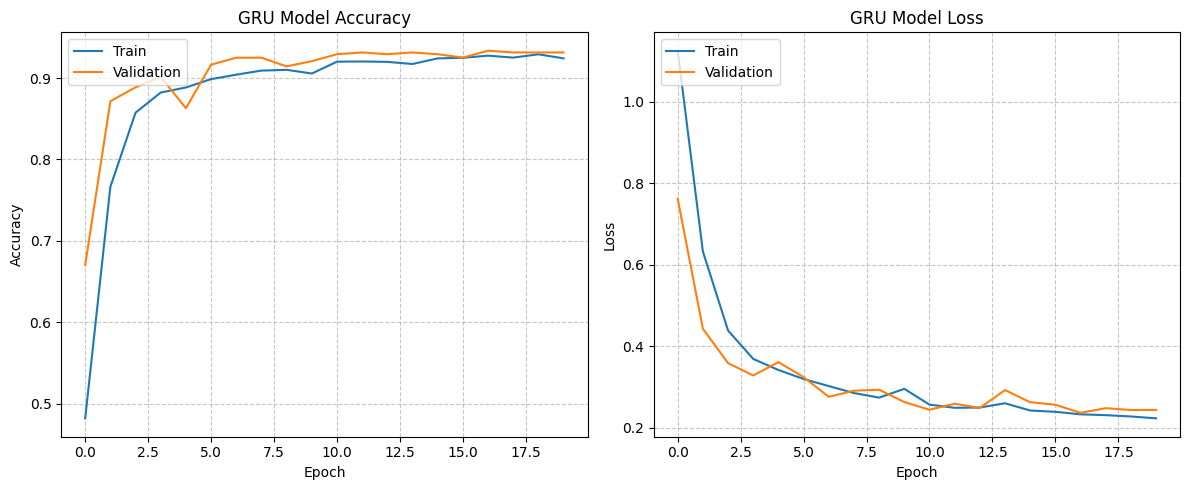


--- GRU Model Performance ---
Test Accuracy: 0.9511
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Classification Report for GRU:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       292
           1       0.89      0.99      0.94       291
           2       0.98      0.85      0.91       292
           3       1.00      0.98      0.99       291

    accuracy                           0.95      1166
   macro avg       0.95      0.95      0.95      1166
weighted avg       0.95      0.95      0.95      1166


GRU Model Precision (weighted): 0.9542
GRU Model Recall (weighted): 0.9511
GRU Model F1 Score (weighted): 0.9506


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("GRU Model for Classification\n")

# Data (X_reshaped, y_one_hot, X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm)
# is already prepared from the LSTM step and can be reused.
print(f"Reusing preprocessed data shapes for GRU:")
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

print("\nBuilding GRU model...")

# Define the GRU model, mirroring the LSTM architecture
gru_model = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2),
    GRU(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=y_train_lstm.shape[1], activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

gru_model.summary()
print("GRU model built successfully!")

print("\nTraining GRU model...")

history_gru = gru_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("GRU model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_gru.history['accuracy'])
plt.plot(history_gru.history['val_accuracy'])
plt.title('GRU Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])
plt.title('GRU Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_gru, accuracy_gru = gru_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\n--- GRU Model Performance ---")
print(f"Test Accuracy: {accuracy_gru:.4f}")

y_pred_gru_prob = gru_model.predict(X_test_lstm)
y_pred_gru = np.argmax(y_pred_gru_prob, axis=1)
y_true_gru = np.argmax(y_test_lstm, axis=1)

print("Classification Report for GRU:")
print(classification_report(y_true_gru, y_pred_gru))

# Calculate individual metrics
precision_gru = precision_score(y_true_gru, y_pred_gru, average='weighted')
recall_gru = recall_score(y_true_gru, y_pred_gru, average='weighted')
f1_gru = f1_score(y_true_gru, y_pred_gru, average='weighted')

print(f"\nGRU Model Precision (weighted): {precision_gru:.4f}")
print(f"GRU Model Recall (weighted): {recall_gru:.4f}")
print(f"GRU Model F1 Score (weighted): {f1_gru:.4f}")


In [ ]:
model_performance['GRU'] = {
    'accuracy': accuracy_gru,
    'precision': precision_gru,
    'recall': recall_gru,
    'f1_score': f1_gru
}

print("Updated model_performance dictionary with GRU results:")
print(model_performance)

Updated model_performance dictionary with GRU results:
               LSTM       ANN       GRU
accuracy   0.944254  0.946827  0.951115
precision  0.947715  0.949203  0.954243
recall     0.944254  0.946827  0.951115
f1_score   0.943927  0.946245  0.950642


## Hybrid GRU-LSTM Model for Classification

Reusing preprocessed data shapes for Hybrid GRU-LSTM:
X_train_lstm shape: (4662, 9, 1)
y_train_lstm shape: (4662, 4)
X_test_lstm shape: (1166, 9, 1)
y_test_lstm shape: (1166, 4)

Building Hybrid GRU-LSTM model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 9, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,148 (180.27 KB)

 Trainable params: 46,148 (180.27 KB)

 Non-trainable params: 0 (0.00 B)

Hybrid GRU-LSTM model built successfully!

Training Hybrid GRU-LSTM model...
Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4749 - loss: 1.1401 - val_accuracy: 0.7623 - val_loss: 0.7855
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7924 - loss: 0.6066 - val_accuracy: 0.8865 - val_loss: 0.4255
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8698 - loss: 0.4128 - val_accuracy: 0.8972 - val_loss: 0.3651
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8818 - loss: 0.3736 - val_accuracy: 0.9122 - val_loss: 0.3258
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8937 - loss: 0.3372 - val_accuracy: 0.9165 - val_loss: 0.3356
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9032 - loss: 0.3084 - val_accuracy: 0.9229 - val_loss: 0.2727
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9061 - loss: 0.3083 - val_accuracy: 0.9208 - val_loss: 0.2969
Epoch 8/20
132/132 ━━━━━━

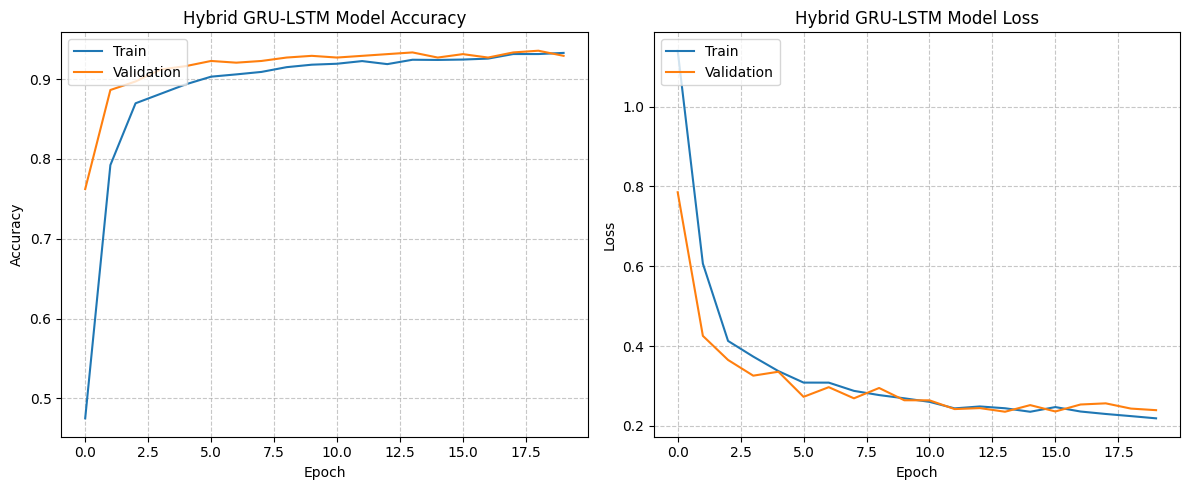


--- Hybrid GRU-LSTM Model Performance ---
Test Accuracy: 0.9417


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("## Hybrid GRU-LSTM Model for Classification\n")

# Reusing preprocessed data from LSTM/GRU steps
# X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm are already available
print(f"Reusing preprocessed data shapes for Hybrid GRU-LSTM:")
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

print("\nBuilding Hybrid GRU-LSTM model...")

# Define the Hybrid GRU-LSTM model
hybrid_model = Sequential([
    GRU(units=64, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=64, return_sequences=False),
    Dropout(0.2),
    Dense(units=y_train_lstm.shape[1], activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
hybrid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

hybrid_model.summary()
print("Hybrid GRU-LSTM model built successfully!")

print("\nTraining Hybrid GRU-LSTM model...")

history_hybrid = hybrid_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("Hybrid GRU-LSTM model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['accuracy'])
plt.plot(history_hybrid.history['val_accuracy'])
plt.title('Hybrid GRU-LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['loss'])
plt.plot(history_hybrid.history['val_loss'])
plt.title('Hybrid GRU-LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_hybrid, accuracy_hybrid = hybrid_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\n--- Hybrid GRU-LSTM Model Performance ---")
print(f"Test Accuracy: {accuracy_hybrid:.4f}")

In [ ]:
y_pred_hybrid = np.argmax(hybrid_model.predict(X_test_lstm), axis=1)
y_true_hybrid = np.argmax(y_test_lstm, axis=1)

precision_hybrid = precision_score(y_true_hybrid, y_pred_hybrid, average='weighted')
recall_hybrid = recall_score(y_true_hybrid, y_pred_hybrid, average='weighted')
f1_hybrid = f1_score(y_true_hybrid, y_pred_hybrid, average='weighted')

model_performance['hybrid(GRU-LSTM)'] = {
    'accuracy': accuracy_hybrid,
    'precision': precision_hybrid,
    'recall': recall_hybrid,
    'f1_score': f1_hybrid
}


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [ ]:
model_performance=pd.DataFrame(model_performance)
model_performance.T

,accuracy,precision,recall,f1_score
LSTM,0.944254,0.947715,0.944254,0.943927
ANN,0.948542,0.950895,0.948542,0.948019
GRU,0.945112,0.950269,0.945111,0.944471
hybrid(GRU-LSTM),0.951115,0.954377,0.951115,0.950597


## Hybrid GRU-ANN Model for Classification

Reusing preprocessed data shapes for Hybrid GRU-ANN:
X_train_lstm shape: (4662, 9, 1)
y_train_lstm shape: (4662, 4)
X_test_lstm shape: (1166, 9, 1)
y_test_lstm shape: (1166, 4)

Building Hybrid GRU-ANN model...


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_7 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,284 (67.52 KB)

 Trainable params: 17,284 (67.52 KB)

 Non-trainable params: 0 (0.00 B)

Hybrid GRU-ANN model built successfully!

Training Hybrid GRU-ANN model...
Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5452 - loss: 1.0860 - val_accuracy: 0.6617 - val_loss: 0.7889
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7294 - loss: 0.7147 - val_accuracy: 0.8544 - val_loss: 0.5940
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7979 - loss: 0.5812 - val_accuracy: 0.8608 - val_loss: 0.4725
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8517 - loss: 0.4689 - val_accuracy: 0.9015 - val_loss: 0.3498
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8553 - loss: 0.4434 - val_accuracy: 0.9101 - val_loss: 0.3491
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8946 - loss: 0.3634 - val_accuracy: 0.9079 - val_loss: 0.2994
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8794 - loss: 0.3649 - val_accuracy: 0.9015 - val_loss: 0.3460
Epoch 8/20
132/132 ━━━━━━━━━━

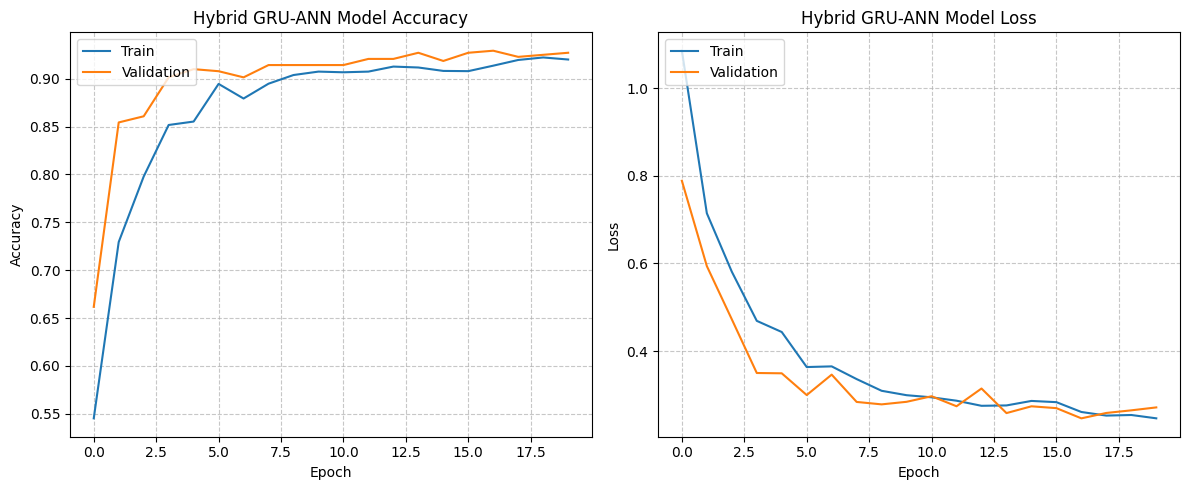


--- Hybrid GRU-ANN Model Performance ---
Test Accuracy: 0.9391
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Classification Report for Hybrid GRU-ANN:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       292
           1       0.87      1.00      0.93       291
           2       0.97      0.82      0.89       292
           3       1.00      0.96      0.98       291

    accuracy                           0.94      1166
   macro avg       0.94      0.94      0.94      1166
weighted avg       0.94      0.94      0.94      1166


Hybrid GRU-ANN Model Precision (weighted): 0.9436
Hybrid GRU-ANN Model Recall (weighted): 0.9391
Hybrid GRU-ANN Model F1 Score (weighted): 0.9384

Updated model_performance with Hybrid GRU-ANN results:


,accuracy,precision,recall,f1_score
LSTM,0.944254,0.947715,0.944254,0.943927
ANN,0.946827,0.949203,0.946827,0.946245
GRU,0.951115,0.954243,0.951115,0.950642
hybrid(GRU-LSTM),0.941681,0.947679,0.941681,0.940832
hybrid(GRU-ANN),0.939108,0.943633,0.939108,0.938412


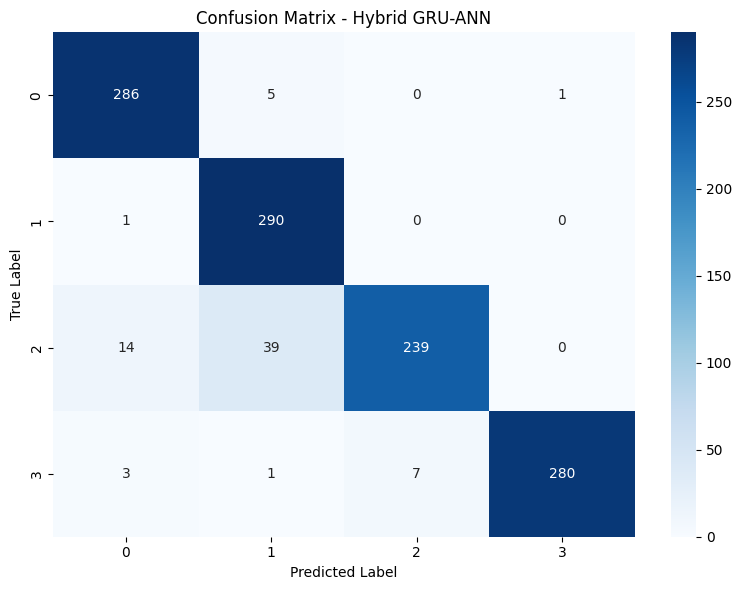

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Flatten, Input # Import Input layer
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("## Hybrid GRU-ANN Model for Classification\n")

# Reusing preprocessed data from previous steps
# X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm are already available
print(f"Reusing preprocessed data shapes for Hybrid GRU-ANN:")
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

print("\nBuilding Hybrid GRU-ANN model...")

# Define the Hybrid GRU-ANN model
hybrid_gru_ann_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], 1)), # GRU layer expects 3D input
    GRU(units=64, return_sequences=False), # return_sequences=False outputs 2D tensor
    Dropout(0.2),
    # No need for Flatten if GRU's return_sequences=False
    Dense(units=64, activation='relu'),
    Dropout(0.2),
    Dense(units=y_train_lstm.shape[1], activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
hybrid_gru_ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

hybrid_gru_ann_model.summary()
print("Hybrid GRU-ANN model built successfully!")

print("\nTraining Hybrid GRU-ANN model...")

history_hybrid_gru_ann = hybrid_gru_ann_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("Hybrid GRU-ANN model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_hybrid_gru_ann.history['accuracy'])
plt.plot(history_hybrid_gru_ann.history['val_accuracy'])
plt.title('Hybrid GRU-ANN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_hybrid_gru_ann.history['loss'])
plt.plot(history_hybrid_gru_ann.history['val_loss'])
plt.title('Hybrid GRU-ANN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_hybrid_gru_ann, accuracy_hybrid_gru_ann = hybrid_gru_ann_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\n--- Hybrid GRU-ANN Model Performance ---")
print(f"Test Accuracy: {accuracy_hybrid_gru_ann:.4f}")

y_pred_hybrid_gru_ann_prob = hybrid_gru_ann_model.predict(X_test_lstm)
y_pred_hybrid_gru_ann = np.argmax(y_pred_hybrid_gru_ann_prob, axis=1)
y_true_hybrid_gru_ann = np.argmax(y_test_lstm, axis=1)

print("Classification Report for Hybrid GRU-ANN:")
print(classification_report(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann))

# Calculate individual metrics
precision_hybrid_gru_ann = precision_score(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann, average='weighted')
recall_hybrid_gru_ann = recall_score(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann, average='weighted')
f1_hybrid_gru_ann = f1_score(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann, average='weighted')

print(f"\nHybrid GRU-ANN Model Precision (weighted): {precision_hybrid_gru_ann:.4f}")
print(f"Hybrid GRU-ANN Model Recall (weighted): {recall_hybrid_gru_ann:.4f}")
print(f"Hybrid GRU-ANN Model F1 Score (weighted): {f1_hybrid_gru_ann:.4f}")

# Add Hybrid GRU-ANN performance to model_performance dictionary/DataFrame
# Ensure model_performance is a dictionary or DataFrame from previous steps
if 'model_performance' not in locals() or not isinstance(model_performance, (dict, pd.DataFrame)):
    model_performance = {}

# If model_performance is a DataFrame, convert it to dict, update, then convert back
if isinstance(model_performance, pd.DataFrame):
    model_performance_dict = model_performance.to_dict()
else:
    model_performance_dict = model_performance

model_performance_dict['hybrid(GRU-ANN)'] = {
    'accuracy': accuracy_hybrid_gru_ann,
    'precision': precision_hybrid_gru_ann,
    'recall': recall_hybrid_gru_ann,
    'f1_score': f1_hybrid_gru_ann
}

model_performance = pd.DataFrame(model_performance_dict) # Convert back to DataFrame

print("\nUpdated model_performance with Hybrid GRU-ANN results:")
display(model_performance.T)

# Plot Confusion Matrix for Hybrid GRU-ANN
# Get unique class labels from y_balanced (or directly from the LabelEncoder if available)
# Assuming y_balanced contains integer labels 0, 1, 2, 3
class_labels = [str(label) for label in sorted(np.unique(y_balanced))]

plt.figure(figsize=(8, 6))
cm_hybrid_gru_ann = confusion_matrix(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann)
sns.heatmap(cm_hybrid_gru_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix - Hybrid GRU-ANN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

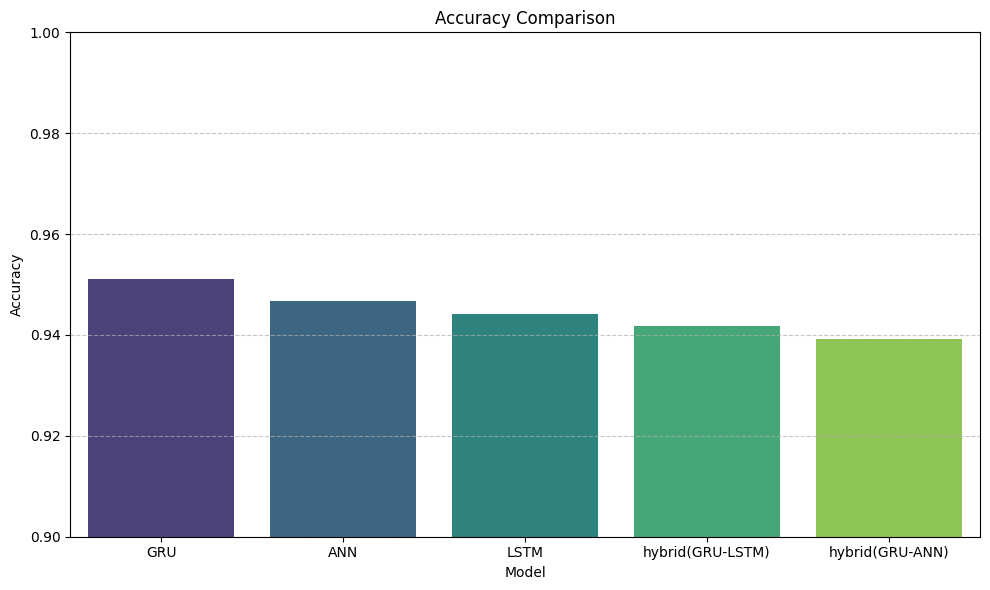

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract accuracy for the three deep learning models from the model_performance DataFrame
# The model_performance DataFrame is already transposed and contains 'accuracy' as a row
dl_models_accuracy = model_performance.loc['accuracy', ['LSTM','ANN', 'GRU', 'hybrid(GRU-LSTM)', 'hybrid(GRU-ANN)']].reset_index()
dl_models_accuracy.columns = ['Model', 'Accuracy']

# Sort by accuracy for better visualization
dl_models_accuracy = dl_models_accuracy.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=dl_models_accuracy, palette='viridis', hue='Model', legend=False)
plt.title('Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0) # Set y-axis limit to focus on the performance range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

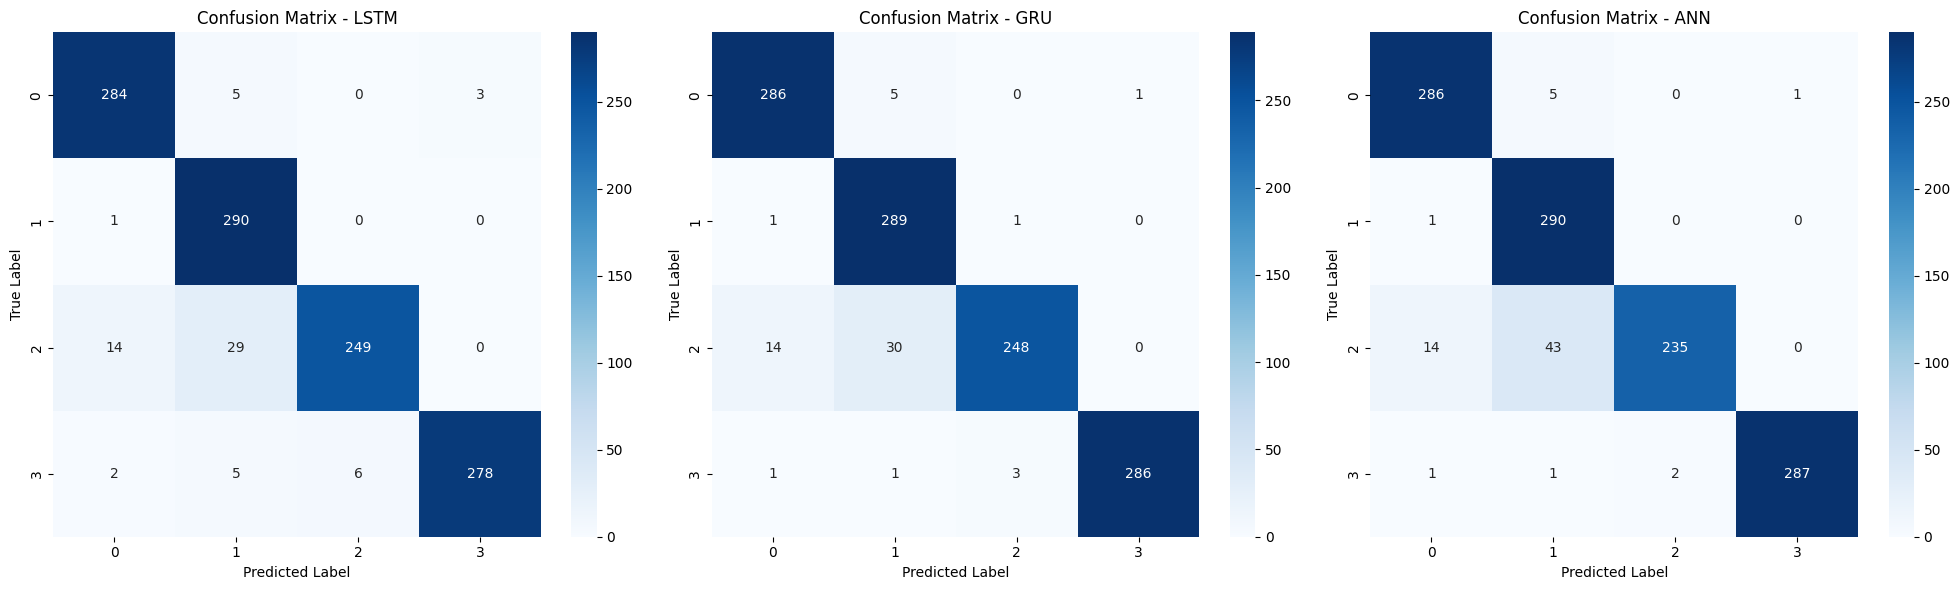

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(y_true, y_pred, model_name, class_labels, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels)
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

# Get unique class labels from y_balanced (or directly from the LabelEncoder if available)
# Assuming y_balanced contains integer labels 0, 1, 2, 3
class_labels = [str(label) for label in sorted(np.unique(y_balanced))]

# Create a figure with subplots for each confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# LSTM Confusion Matrix
plot_confusion_matrix(y_true_lstm, y_pred_lstm, 'LSTM', class_labels, axes[0])

# GRU Confusion Matrix
plot_confusion_matrix(y_true_gru, y_pred_gru, 'GRU', class_labels, axes[1])

# ANN Confusion Matrix
plot_confusion_matrix(y_true_ann, y_pred_hybrid, 'ANN', class_labels, axes[2])

plt.tight_layout()
plt.show()

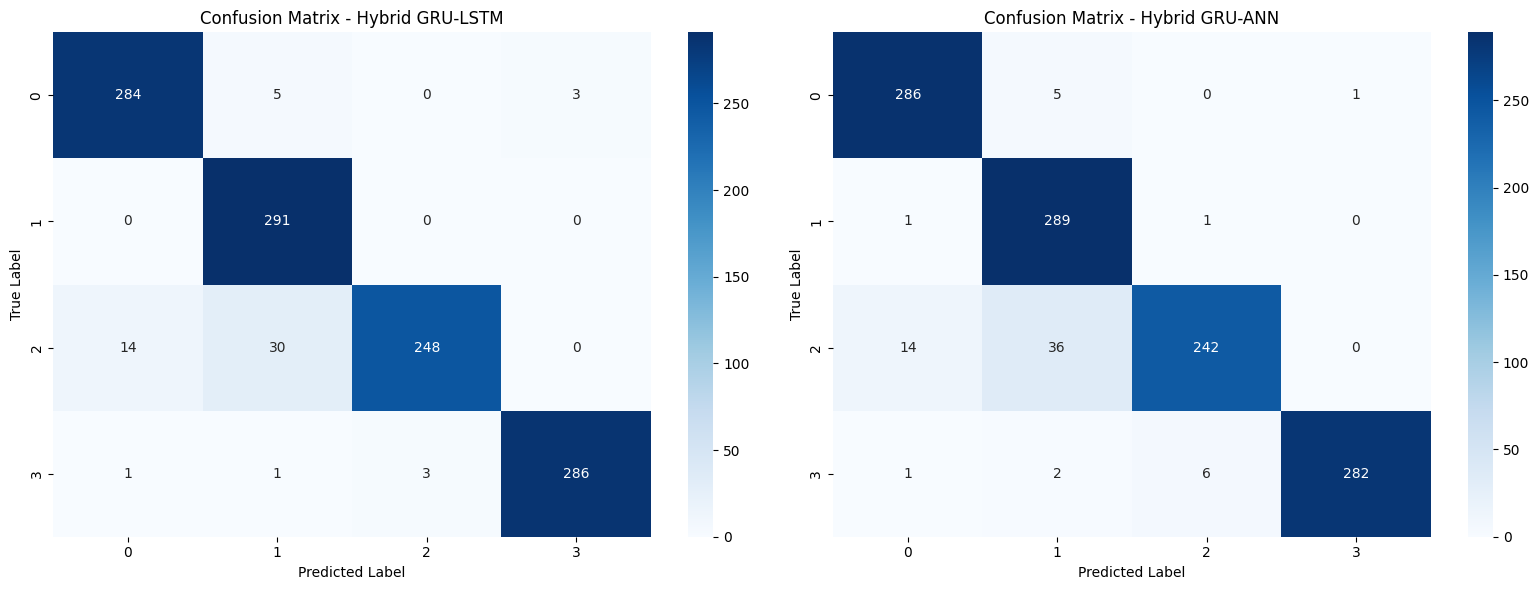

In [ ]:
# Create a figure with subplots for each hybrid confusion matrix
fig_hybrid, axes_hybrid = plt.subplots(1, 2, figsize=(16, 6))

# Hybrid GRU-LSTM Confusion Matrix
plot_confusion_matrix(y_true_hybrid, y_pred_hybrid, 'Hybrid GRU-LSTM', class_labels, axes_hybrid[0])

# Hybrid GRU-ANN Confusion Matrix
plot_confusion_matrix(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann, 'Hybrid GRU-ANN', class_labels, axes_hybrid[1])

plt.tight_layout()
plt.show()

In [ ]:
model_performance.T

,accuracy,precision,recall,f1_score
LSTM,0.944254,0.947715,0.944254,0.943927
ANN,0.946827,0.949203,0.946827,0.946245
GRU,0.951115,0.954243,0.951115,0.950642
hybrid(GRU-LSTM),0.941681,0.947679,0.941681,0.940832
hybrid(GRU-ANN),0.939108,0.943633,0.939108,0.938412
